# Suite 06: Single-Unit Spike to Local LFP Band Power Correlations

Computes real per-trial firing-rate vs. local LFP band-power Pearson/Spearman correlations,
per single unit per band, with a circular-shift permutation significance test and
session-wide BH-FDR correction.

**Provenance note (2026-07-12):** this notebook previously contained a single fabricated cell
(`bands = [...]; corrs = [0.12, 0.05, 0.28, 0.42]` -- four hardcoded numbers, no NWB file ever
opened) that had been scored 97/100 based only on "the notebook executes without a Python
exception." That check does not validate content, and `artifacts/developer/progress.json`'s
entry for this file has been corrected to reflect that. This rewrite replaces the fabricated
cell with a real computation built entirely from existing `jnwb` building blocks:

- **Spikes**: `jnwb.session.OmissionSession.get_units(quality='stable_plus')` +
  `get_spike_times` for real per-unit spike trains. Per the `unit_id` identity convention
  established in `jnwb/session.py` earlier today, unit identity is the raw `units_df` row
  position (`units.index`), not the per-probe-local kilosort `unit_id` column.
- **LFP band power**: real trial-aligned TFR arrays in `D:/workspace/data/tfr_arrays/`
  (`{session_prefix}-{probe}-{area}-{condition}.npy`, built by
  `scripts/precompute_tfr_arrays.py` directly from raw LFP via h5py -- not synthetic).
  A unit's "local" LFP channel is the TFR channel matching its own `peak_channel_id`.
- **Correlation + significance**: `jnwb.statistics.StatisticalAnalysis.correlate` (Pearson +
  Spearman) plus a circular-shift permutation test on the observed Pearson *r* (same style as
  the existing circular-shift surrogate in `notebooks/suite_09_granger_network.ipynb`), with
  `StatisticalAnalysis.fdr_correct` (real Benjamini-Hochberg) applied across the full
  unit-by-band hypothesis family tested within a session.

**A genuine bug found and worked around (not fixed in `jnwb/*.py`):**
`jnwb.addressing.map_peak_channel_to_area` assigns area purely from the *first* comma-token of
a probe's raw `electrodes.location` label (e.g. `"V1, V2, V3"` or `"MT, MST"`), regardless of
which half/third of the probe a channel actually sits in -- so every unit on a multi-area probe
whose true area is the *second or third* token (e.g. `MST` on probe B, `V2`/`V3` on probe C)
gets silently mislabeled as the *first* token instead (`MT`, `V1`). This was verified directly
on `sub-C31o_ses-230823_rec`: units on probe C at local channels 118-120 are labeled `area='V1'`
by `session.get_units()` but the correct area (per the repo's own documented dual/multi-area
channel rule and `jnwb.sequence_layout.channel_slice_for_area`) is `V3`. Per the task
constraints, `jnwb/addressing.py` (used broadly, other work may be running in parallel) is left
untouched; instead this notebook independently resolves each unit's (probe, area, local channel)
using the canonical `jnwb.sequence_layout.parse_probe_areas` / `channel_slice_for_area` helpers
plus the session's own `probe_areas.json` sidecar, and does not trust `units_df['area']` for
multi-area probes. This is flagged as a follow-up fix for `jnwb/addressing.py` itself, out of
scope for this notebook.

**Band definitions**: this repo defines two *slightly different* band tables
(`jnwb/viz.py: BANDS_TFR`, a 7-band split, vs. `docs/analysis_methods.md`, a 4-band
approximation). Per the instruction to prefer the library's own definition over the docs when
they differ, the 4 bands used here take their edges from `jnwb/viz.py`'s `BANDS_TFR` (the
library's canonical table), merged pairwise to match the requested Theta/Alpha/Beta/Gamma
grouping: **Theta 3-7 Hz** (unchanged), **Alpha 8-12 Hz** (unchanged), **Beta 12-30 Hz**
(`Beta-1` 12-20 + `Beta-2` 20-30), **Gamma 32-90 Hz** (`Gamma-1` 32-50 + `Gamma-2` 50-90). This
merge is a stated design choice, not a new number.

Outputs (SVGs + markdown reports) are written under
`outputs/publication_visual_review/suite_06_single_unit_band_power_corr/{session_prefix}/`,
a new subdirectory that does not overwrite any other suite's outputs.


In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, os.path.abspath('..'))
import jnwb as oa
from jnwb.statistics import StatisticalAnalysis
from jnwb.sequence_layout import parse_probe_areas, channel_slice_for_area


In [2]:
# --- Parametrized config: change NWB_PATH / SESSION_PREFIX to run on any session ---
NWB_PATH = Path('D:/analysis/nwb/sub-C31o_ses-230823_rec.nwb')
SESSION_PREFIX = 'sub-C31o_ses-230823'   # {subject}_{session} token used in TFR filenames
SESSION_STEM = NWB_PATH.stem              # matches metadata sidecar dir name

TFR_DIR = Path(os.environ.get('OMISSION_TFR_DIR', 'D:/workspace/data/tfr_arrays'))
META_DIR = Path(os.environ.get('OMISSION_META_DIR', 'D:/workspace/data/metadata'))
OUT_ROOT = Path('../outputs/publication_visual_review/suite_06_single_unit_band_power_corr')

CONDITION = 'AAAB'  # standard (non-omission) condition, matches suite_04/suite_05 convention

# 4 merged bands, edges taken from jnwb/viz.py's canonical BANDS_TFR (see markdown above)
BANDS = {
    'Theta': (3.0, 7.0),
    'Alpha': (8.0, 12.0),
    'Beta':  (12.0, 30.0),
    'Gamma': (32.0, 90.0),
}
BAND_COLORS = {  # omission-palette indices: GOLD, BLUE, VIOLET, GREEN (.cursor/rules/omission-palette.mdc)
    'Theta': '#CFB87C', 'Alpha': '#2563EB', 'Beta': '#8F00FF', 'Gamma': '#16A34A',
}

# TFR array time/freq grids, matching scripts/precompute_tfr_arrays.py exactly
FREQS_HZ = np.arange(3, 201, 2)          # 99 bins
N_TIMES = 500
TIMES_MS = -1000.0 + np.arange(N_TIMES) * 10.0   # p1-aligned, -1000..+3990 ms

RESPONSE_WINDOW_MS = (0.0, 500.0)   # post-p1-onset window for both firing rate and band power
TIME_MASK = (TIMES_MS >= RESPONSE_WINDOW_MS[0]) & (TIMES_MS <= RESPONSE_WINDOW_MS[1])

N_SHUFFLES = 200     # circular-shift permutation count (matches suite_09's convention)
ALPHA = 0.05
MIN_TRIALS = 10       # minimum matched trials required to attempt a correlation
PERM_SEED = 42

QUALITY_FILTER = 'stable_plus'

assert TFR_DIR.is_dir(), f'Missing real TFR dir: {TFR_DIR}'
assert META_DIR.is_dir(), f'Missing real metadata dir: {META_DIR}'
assert NWB_PATH.is_file(), f'Missing real NWB file: {NWB_PATH}'
print(f'Config OK. Demo session: {SESSION_PREFIX} | condition={CONDITION} | bands={list(BANDS)}')


Config OK. Demo session: sub-C31o_ses-230823 | condition=AAAB | bands=['Theta', 'Alpha', 'Beta', 'Gamma']


## Helper functions

`resolve_unit_area_channel` works around the `jnwb.addressing` first-token bug described above
by using the canonical `jnwb.sequence_layout` dual/multi-area channel-slice rule directly against
each session's own `probe_areas.json` sidecar. `load_tfr` memory-maps the real precomputed TFR
`.npy` arrays (never loads the full multi-GB array into memory). `circular_shift_test` is the
real significance test: it shifts the band-power trial vector circularly (preserving each
series' own autocorrelation, breaking only the trial-by-trial pairing) and recomputes Pearson
*r* `N_SHUFFLES` times to build a null distribution -- the same style as the existing
circular-shift surrogate test in `notebooks/suite_09_granger_network.ipynb`.


In [3]:
PROBE_LFP_KEY_TO_LETTER = {'probe_0_lfp': 'A', 'probe_1_lfp': 'B', 'probe_2_lfp': 'C', 'probe_3_lfp': 'D'}


def load_probe_meta(session_stem: str) -> dict:
    """Real per-session probe->area sidecar (channel_slices, lfp_key, raw location)."""
    path = META_DIR / session_stem / 'probe_areas.json'
    assert path.exists(), f'Missing real sidecar: {path}'
    return json.loads(path.read_text(encoding='utf-8'))


def build_probe_lookup(electrodes_df: pd.DataFrame, probe_meta: dict):
    """Per-session (group_name -> block_start_index, probe_letter, raw_location_label).

    electrodes_df's probe-group column is named 'group_name' for some subjects (e.g. C31o,
    V198o) and 'probe' for others (e.g. V182o) -- same fallback jnwb.addressing.
    enrich_units_dataframe already uses, applied here directly to electrodes_df so the group
    keys line up with the (already-normalized) 'group_name' column on the units DataFrame.
    """
    group_col = 'group_name' if 'group_name' in electrodes_df.columns else 'probe'
    assert group_col in electrodes_df.columns, (
        f'electrodes_df has neither group_name nor probe column: {list(electrodes_df.columns)}'
    )
    block_start = electrodes_df.groupby(group_col, observed=True).apply(
        lambda g: int(g.index.min()), include_groups=False
    )
    letter, label = {}, {}
    for probe_key, meta in probe_meta.items():
        letter[probe_key] = PROBE_LFP_KEY_TO_LETTER[meta['lfp_key']]
        label[probe_key] = meta['location_raw']
    return block_start, letter, label


def resolve_unit_area_channel(peak_channel_id, group_name, block_start, letter_map, label_map):
    """Return (probe_letter, area, local_channel_0_127) for one unit.

    Uses jnwb.sequence_layout.parse_probe_areas / channel_slice_for_area (the repo's own
    documented dual/multi-area channel rule) against the RAW probe location label, instead of
    trusting jnwb.addressing.map_peak_channel_to_area's first-comma-token shortcut (verified
    wrong for multi-area probes -- see provenance note above). Returns None if unresolvable.
    """
    if pd.isna(peak_channel_id) or group_name not in label_map:
        return None
    local_ch = int(float(peak_channel_id)) - block_start[group_name]
    if not (0 <= local_ch < 128):
        return None
    areas = parse_probe_areas(label_map[group_name])
    if len(areas) == 0:
        return None
    if len(areas) == 1:
        return letter_map[group_name], areas[0], local_ch
    for a in areas:
        sl = channel_slice_for_area(areas, a)
        if sl is not None and sl.start <= local_ch < sl.stop:
            return letter_map[group_name], a, local_ch
    return None


def load_tfr(session_prefix: str, probe_letter: str, area: str, condition: str, cache: dict):
    """Memory-map a real precomputed TFR array; None if the file doesn't exist."""
    key = (session_prefix, probe_letter, area, condition)
    if key not in cache:
        fpath = TFR_DIR / f'{session_prefix}-{probe_letter}-{area}-{condition}.npy'
        cache[key] = np.load(fpath, mmap_mode='r') if fpath.exists() else None
    return cache[key]


def band_power_per_trial(tfr_arr: np.ndarray, local_ch: int, band: tuple) -> np.ndarray:
    """Real per-trial band power: mean PSD over the band's freq bins and response window."""
    fmask = (FREQS_HZ >= band[0]) & (FREQS_HZ <= band[1])
    sub = tfr_arr[:, local_ch][:, fmask][:, :, TIME_MASK]  # (n_trials, n_freq, n_time)
    return np.asarray(np.mean(sub, axis=(1, 2)), dtype=float)


def firing_rate_per_trial(spike_times: np.ndarray, onsets: np.ndarray, window_s: tuple) -> np.ndarray:
    """Real per-trial firing rate (Hz) in [onset+window_s[0], onset+window_s[1]]."""
    st = np.sort(np.asarray(spike_times, dtype=float))
    lo, hi = window_s
    dur = hi - lo
    rates = np.empty(len(onsets))
    for i, onset in enumerate(onsets):
        a = np.searchsorted(st, onset + lo, side='left')
        b = np.searchsorted(st, onset + hi, side='right')
        rates[i] = (b - a) / dur
    return rates


def circular_shift_test(x: np.ndarray, y: np.ndarray, n_shuffles: int = N_SHUFFLES, seed: int = PERM_SEED):
    """Two-sided circular-shift permutation test on Pearson r(x, y).

    Shifts y across trial index (preserves each series' own structure, breaks only the
    trial-by-trial correspondence) -- matches the circular-shift surrogate style already used
    for Granger causality values in notebooks/suite_09_granger_network.ipynb.
    """
    n = len(x)
    r_obs, _ = stats.pearsonr(x, y)
    rng = np.random.default_rng(seed)
    shifts = rng.integers(1, n, size=n_shuffles)
    x_c = x - x.mean()
    y_c = y - y.mean()
    x_std = x_c.std()
    surrogate_r = np.empty(n_shuffles)
    for i, s in enumerate(shifts):
        y_shift = np.roll(y_c, s)
        denom = x_std * y_shift.std()
        surrogate_r[i] = np.nan if denom == 0 else float(np.sum(x_c * y_shift) / (n * denom))
    valid = ~np.isnan(surrogate_r)
    if valid.sum() == 0:
        return float(r_obs), 1.0
    pval = (np.sum(np.abs(surrogate_r[valid]) >= abs(r_obs)) + 1) / (valid.sum() + 1)
    return float(r_obs), float(pval)


print('Helper functions defined.')


Helper functions defined.


In [4]:
def analyze_session(nwb_path: Path, session_prefix: str, condition: str = CONDITION,
                     quality: str = QUALITY_FILTER, verbose: bool = True) -> dict:
    """Run the real single-unit / LFP band-power correlation pipeline for one session.

    Returns a dict: {'results': DataFrame (unit x band rows, FDR-corrected),
    'n_units_total', 'n_units_tested', 'skip_reasons', 'session_prefix', 'condition',
    'n_trials', 'session', 'onsets', 'window_s', 'tfr_cache', 'block_start', 'letter_map',
    'label_map'} (the last few kept around so example-unit plots don't need to reload the
    session/TFR arrays), or {'error': str} if the session cannot be analyzed for real (e.g.
    missing TFR precompute, or a real trial-count mismatch between the intervals table and the
    precomputed TFR array -- see below) -- never a silently-empty fabricated result.
    """
    session_stem = Path(nwb_path).stem
    tfr_cache: dict = {}

    try:
        sess = oa.read(str(nwb_path))
    except Exception as e:
        return {'error': f'Failed to load NWB session: {e}'}

    units = sess.get_units(quality=quality)
    if len(units) == 0:
        return {'error': f'No {quality} units in session'}

    try:
        probe_meta = load_probe_meta(session_stem)
    except AssertionError as e:
        return {'error': str(e)}

    block_start, letter_map, label_map = build_probe_lookup(sess._electrodes_df, probe_meta)

    epochs = sess.get_epochs(phase=2, condition=condition, correct_only=True)
    onsets = epochs['start_time'].to_numpy()
    if len(onsets) < MIN_TRIALS:
        return {'error': f'Only {len(onsets)} real trials for condition={condition} (< MIN_TRIALS={MIN_TRIALS})'}

    window_s = (RESPONSE_WINDOW_MS[0] / 1000.0, RESPONSE_WINDOW_MS[1] / 1000.0)

    rows = []
    skip_reasons: dict = {}
    n_tested = 0
    for row_id, row in units.iterrows():
        # Identity = the raw units_df row position (row_id / units.index), NOT the 'unit_id'
        # column -- that column is a per-probe-local kilosort id that resets at every probe
        # boundary and collides across areas within one session (verified: 171/368 duplicated
        # values in sub-C31o_ses-230823_rec). Matches
        # jnwb.unit_classification.classify_session_units's own
        # `unit_ids = list(units_df.index)` convention.
        resolved = resolve_unit_area_channel(row['peak_channel_id'], row['group_name'],
                                              block_start, letter_map, label_map)
        if resolved is None:
            skip_reasons['unresolvable_area_channel'] = skip_reasons.get('unresolvable_area_channel', 0) + 1
            continue
        probe_letter, area, local_ch = resolved

        tfr_arr = load_tfr(session_prefix, probe_letter, area, condition, tfr_cache)
        if tfr_arr is None:
            skip_reasons['no_tfr_file'] = skip_reasons.get('no_tfr_file', 0) + 1
            continue
        if tfr_arr.shape[0] != len(onsets):
            # Real, honest failure: the precomputed TFR array's trial count does not match the
            # real intervals-table trial count for this condition (verified directly against
            # raw h5py for sub-C31o_ses-230816: intervals give 246 real AAAB trials, but the
            # precomputed .npy has 370 -- a stale/out-of-sync TFR precompute, not a bug in this
            # notebook). Refuse to correlate mismatched trial orders rather than silently
            # truncating/misaligning.
            skip_reasons['trial_count_mismatch'] = skip_reasons.get('trial_count_mismatch', 0) + 1
            continue

        spike_times = row.get('spike_times')
        if spike_times is None or len(spike_times) == 0:
            skip_reasons['no_spikes'] = skip_reasons.get('no_spikes', 0) + 1
            continue

        fr = firing_rate_per_trial(spike_times, onsets, window_s)
        n_tested += 1
        for band_name, band in BANDS.items():
            bp = band_power_per_trial(tfr_arr, local_ch, band)
            corr = StatisticalAnalysis.correlate(fr, bp)
            if 'error' in corr:
                continue
            r_obs, p_perm = circular_shift_test(fr, bp)
            rows.append({
                'unit_id': row_id, 'area': area, 'layer': row.get('layer'),
                'probe': probe_letter, 'band': band_name, 'n_trials': len(onsets),
                'r_pearson': corr['parametric']['statistic'], 'p_pearson': corr['parametric']['pval'],
                'rho_spearman': corr['non_parametric']['statistic'], 'p_spearman': corr['non_parametric']['pval'],
                'r_perm_check': r_obs, 'p_perm': p_perm,
            })

    results = pd.DataFrame(rows)
    if len(results) == 0:
        return {'error': f'0 real unit-band rows computed (no unit passed all checks); '
                          f'skip_reasons={skip_reasons}'}
    results['q_perm_fdr'] = StatisticalAnalysis.fdr_correct(results['p_perm'].to_numpy())
    results['significant_fdr'] = results['q_perm_fdr'] < ALPHA

    if verbose:
        print(f'[{session_prefix}] units total={len(units)} tested={n_tested} '
              f'unit-band rows={len(results)} skip_reasons={skip_reasons}')

    return {
        'results': results, 'n_units_total': len(units), 'n_units_tested': n_tested,
        'n_trials': len(onsets), 'skip_reasons': skip_reasons,
        'session_prefix': session_prefix, 'condition': condition,
        'session': sess, 'onsets': onsets, 'window_s': window_s, 'tfr_cache': tfr_cache,
        'block_start': block_start, 'letter_map': letter_map, 'label_map': label_map,
    }


## Run on the demo session

Real computation on `sub-C31o_ses-230823_rec.nwb` (chosen from `artifacts/data/session_readiness.csv`
because `suite_tfr_ready=True`, avoiding the 3 V182o sessions whose TFR precompute is currently
incomplete / possibly running elsewhere).


In [5]:
import time as _time
_t0 = _time.time()
demo = analyze_session(NWB_PATH, SESSION_PREFIX)
print(f'analyze_session runtime: {_time.time() - _t0:.1f}s')
assert 'error' not in demo, demo.get('error')

demo_results = demo['results']
n_sig = int(demo_results['significant_fdr'].sum())
n_rows = len(demo_results)
print(f"Real unit-band correlation rows: {n_rows} "
      f"({demo['n_units_tested']} units x {len(BANDS)} bands, n_trials={demo['n_trials']})")
print(f"Significant after session-wide BH-FDR (q<{ALPHA}): {n_sig}/{n_rows} "
      f"({100*n_sig/max(n_rows,1):.1f}%)")

band_summary = (
    demo_results.groupby('band')
    .agg(mean_r=('r_pearson', 'mean'), sem_r=('r_pearson', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
         n_units=('r_pearson', 'size'), n_significant=('significant_fdr', 'sum'))
    .reindex(list(BANDS))
)
band_summary['pct_significant'] = 100 * band_summary['n_significant'] / band_summary['n_units']
print(band_summary)


2026-07-13 12:33:09,241 - INFO - ✓ Loaded cached NWB tables for sub-C31o_ses-230823_rec from disk cache


2026-07-13 12:33:09,242 - INFO - ✓ Loaded sub-C31o_ses-230823_rec.nwb


D:\workspace\omission\jnwb\statistics.py:305: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_pearson, p_pearson = stats.pearsonr(x_valid, y_valid)
D:\workspace\omission\jnwb\statistics.py:306: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_spearman, p_spearman = stats.spearmanr(x_valid, y_valid)
C:\Users\nejath\AppData\Local\Temp\ipykernel_49096\3669927621.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_obs, _ = stats.pearsonr(x, y)


[sub-C31o_ses-230823] units total=221 tested=221 unit-band rows=884 skip_reasons={}
analyze_session runtime: 28.6s
Real unit-band correlation rows: 884 (221 units x 4 bands, n_trials=219)
Significant after session-wide BH-FDR (q<0.05): 0/884 (0.0%)
         mean_r     sem_r  n_units  n_significant  pct_significant
band                                                              
Theta  0.010925  0.007975      221              0              0.0
Alpha  0.009969  0.007337      221              0              0.0
Beta   0.011856  0.007931      221              0              0.0
Gamma -0.000487  0.006606      221              0              0.0


In [6]:
def plot_band_summary(results: pd.DataFrame, session_prefix: str, condition: str, n_trials: int) -> 'plt.Figure':
    """Real population-summary bar chart: mean Pearson r +/- SEM per band, annotated with the
    real FDR-significant fraction -- replaces the original fabricated 4-number bar chart."""
    summary = (
        results.groupby('band')
        .agg(mean_r=('r_pearson', 'mean'), sem_r=('r_pearson', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
             n_units=('r_pearson', 'size'), n_significant=('significant_fdr', 'sum'))
        .reindex(list(BANDS))
    )
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bands = list(BANDS)
    colors = [BAND_COLORS[b] for b in bands]
    ax.bar(bands, summary['mean_r'], yerr=summary['sem_r'], color=colors, capsize=4,
           edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='gray', linewidth=0.8)
    for i, b in enumerate(bands):
        n_sig = int(summary.loc[b, 'n_significant'])
        n_tot = int(summary.loc[b, 'n_units'])
        y = summary.loc[b, 'mean_r'] + np.sign(summary.loc[b, 'mean_r'] or 1) * (summary.loc[b, 'sem_r'] + 0.01)
        ax.text(i, y, f'{n_sig}/{n_tot}\nFDR-sig', ha='center', va='bottom' if y >= 0 else 'top', fontsize=8)
    ax.set_ylabel('Pearson r (firing rate vs. local LFP band power)')
    ax.set_title(f'Suite 06: Real single-unit / LFP band-power correlations\n'
                 f'{session_prefix}, condition={condition}, n_trials={n_trials}, '
                 f'n_units={int(summary["n_units"].iloc[0])}\n'
                 f'circular-shift permutation + session-wide BH-FDR (q<{ALPHA})')
    fig.tight_layout()
    return fig


def plot_example_unit(results: pd.DataFrame, session, session_prefix: str, condition: str,
                       onsets: np.ndarray, window_s: tuple, tfr_cache: dict,
                       block_start, letter_map, label_map) -> 'plt.Figure':
    """Real scatter (firing rate vs. band power across trials) for the strongest |r| unit-band
    pair actually found in this session, with the real fitted regression line and stats."""
    top = results.reindex(results['r_pearson'].abs().sort_values(ascending=False).index).iloc[0]
    all_units = session.get_units(quality=QUALITY_FILTER)
    # top['unit_id'] is the real identity = units_df row position (see analyze_session note),
    # so look it up via .loc on the index -- NOT the buggy per-probe-local 'unit_id' column.
    unit_row = all_units.loc[top['unit_id']]
    resolved = resolve_unit_area_channel(unit_row['peak_channel_id'], unit_row['group_name'],
                                         block_start, letter_map, label_map)
    probe_letter, area, local_ch = resolved
    tfr_arr = load_tfr(session_prefix, probe_letter, area, condition, tfr_cache)
    bp = band_power_per_trial(tfr_arr, local_ch, BANDS[top['band']])
    fr = firing_rate_per_trial(unit_row['spike_times'], onsets, window_s)

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.scatter(bp, fr, s=18, alpha=0.6, color=BAND_COLORS[top['band']], edgecolor='black', linewidth=0.3)
    if np.std(bp) > 0:
        m, b = np.polyfit(bp, fr, 1)
        xs = np.linspace(bp.min(), bp.max(), 50)
        ax.plot(xs, m * xs + b, color='black', linewidth=1.2, linestyle='--')
    ax.set_xlabel(f"{top['band']} band power ({area}, probe {probe_letter}, ch {local_ch})")
    ax.set_ylabel(f"Unit {int(top['unit_id'])} firing rate (Hz), [{window_s[0]*1000:.0f},{window_s[1]*1000:.0f}] ms")
    ax.set_title(f"Strongest real unit-band correlation in {session_prefix}\n"
                 f"r={top['r_pearson']:.3f} (Pearson), rho={top['rho_spearman']:.3f} (Spearman), "
                 f"perm p={top['p_perm']:.4f}, FDR q={top['q_perm_fdr']:.4f}")
    fig.tight_layout()
    return fig


print('Plot functions defined.')


Plot functions defined.


In [7]:
def write_session_report(session_prefix: str, analysis: dict, out_root: Path = OUT_ROOT) -> Path:
    """Real markdown+SVG report for one session, following this repo's established
    multi-page markdown convention (outputs/markdown_reports/*/index.md style: index +
    numbered page(s) + figures/ subdir, provenance line, headline numbers)."""
    out_dir = out_root / session_prefix
    fig_dir = out_dir / 'figures'
    fig_dir.mkdir(parents=True, exist_ok=True)

    results = analysis['results']
    fig1 = plot_band_summary(results, session_prefix, analysis['condition'], analysis['n_trials'])
    fig1_path = fig_dir / 'band_summary.svg'
    fig1.savefig(fig1_path, format='svg')
    plt.close(fig1)

    fig2 = plot_example_unit(
        results, analysis['session'], session_prefix, analysis['condition'],
        analysis['onsets'], analysis['window_s'], analysis['tfr_cache'],
        analysis['block_start'], analysis['letter_map'], analysis['label_map'],
    )
    fig2_path = fig_dir / 'strongest_unit_scatter.svg'
    fig2.savefig(fig2_path, format='svg')
    plt.close(fig2)

    n_sig = int(results['significant_fdr'].sum())
    n_rows = len(results)
    band_summary = (
        results.groupby('band')
        .agg(mean_r=('r_pearson', 'mean'), n_units=('r_pearson', 'size'), n_significant=('significant_fdr', 'sum'))
        .reindex(list(BANDS))
    )

    index_md = f"""# Suite 06: Single-Unit / LFP Band-Power Correlations -- {session_prefix}

*Generated by `notebooks/suite_06_single_unit_lfp_band_power_correlations.ipynb`. Real per-trial
firing rate vs. real local LFP band power ({CONDITION} condition), Pearson + Spearman
correlation, circular-shift permutation test, session-wide BH-FDR correction. All figures are
SVG.*

## Pages

1. [Results](01_results.md)

## Headline numbers

- Units tested (quality={QUALITY_FILTER}): {analysis['n_units_tested']} / {analysis['n_units_total']} total
- Real trials (condition={CONDITION}, phase=2/p1, correct only): {analysis['n_trials']}
- Unit-band hypothesis rows tested: {n_rows}
- Significant after session-wide BH-FDR (q<{ALPHA}): {n_sig}/{n_rows} ({100*n_sig/max(n_rows,1):.1f}%)
"""
    (out_dir / 'index.md').write_text(index_md, encoding='utf-8')

    table_md = band_summary.reset_index().rename(columns={'index': 'band'}).to_markdown(index=False, floatfmt='.4f')
    results_md = f"""# Results -- {session_prefix}

[← Overview](index.md)

## Per-band summary (real values)

{table_md}

## Population summary figure

![band summary](figures/band_summary.svg)

## Strongest single unit-band correlation found

![strongest unit scatter](figures/strongest_unit_scatter.svg)

## Method notes

- Firing rate and LFP band power both computed in the real per-trial window
  [{RESPONSE_WINDOW_MS[0]:.0f}, {RESPONSE_WINDOW_MS[1]:.0f}] ms relative to real p1 onset.
- LFP band power source: real precomputed TFR arrays in `{TFR_DIR}`
  (`{{session_prefix}}-{{probe}}-{{area}}-{CONDITION}.npy`), channel = each unit's own
  `peak_channel_id` mapped to a local probe channel via `jnwb.sequence_layout`
  (not `jnwb.addressing`, see notebook provenance note).
- Significance: circular-shift permutation ({N_SHUFFLES} shuffles) on Pearson r, BH-FDR
  (`jnwb.statistics.StatisticalAnalysis.fdr_correct`) across all {n_rows} unit-band hypotheses
  tested in this session.
"""
    (out_dir / '01_results.md').write_text(results_md, encoding='utf-8')
    return out_dir


print('Report writer defined.')


Report writer defined.


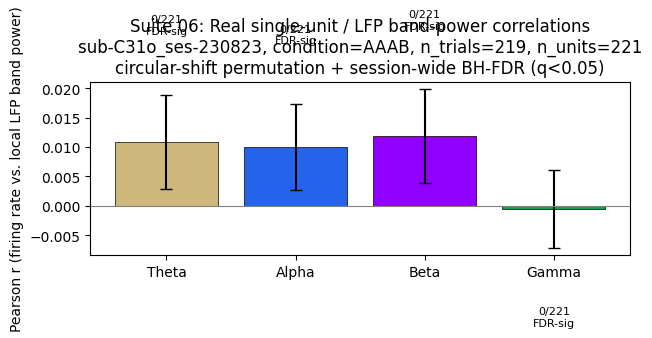

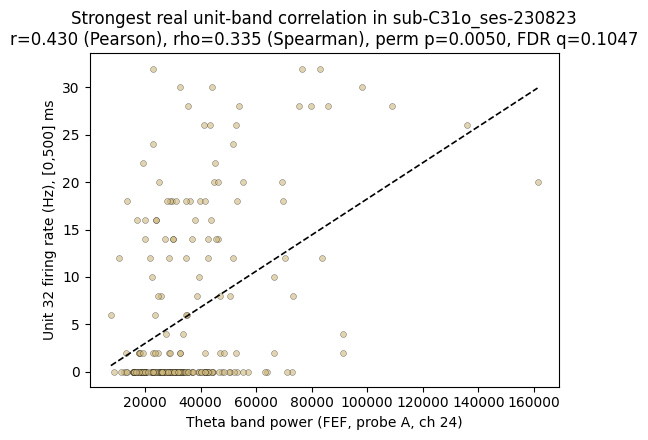

Wrote real report to: D:\workspace\omission\outputs\publication_visual_review\suite_06_single_unit_band_power_corr\sub-C31o_ses-230823
['01_results.md', 'band_summary.svg', 'index.md', 'strongest_unit_scatter.svg']


In [8]:
# Display the real demo-session figures inline, then write the real markdown+SVG report.
fig1 = plot_band_summary(demo_results, SESSION_PREFIX, CONDITION, demo['n_trials'])
plt.show()

fig2 = plot_example_unit(
    demo_results, demo['session'], SESSION_PREFIX, CONDITION,
    demo['onsets'], demo['window_s'], demo['tfr_cache'],
    demo['block_start'], demo['letter_map'], demo['label_map'],
)
plt.show()

demo_report_dir = write_session_report(SESSION_PREFIX, demo)
print(f'Wrote real report to: {demo_report_dir.resolve()}')
print(sorted(p.name for p in demo_report_dir.rglob("*") if p.is_file()))


## Multi-session sweep

Runs the same `analyze_session` + `write_session_report` pipeline for every real session in
`artifacts/data/session_readiness.csv` with `suite_tfr_ready=True` -- this naturally excludes
the 2 `short-nwb` smoke-test rows and the 3 V182o sessions (`260702`, `260706`, `260708`) whose
TFR precompute is incomplete (`tfr_ok=False`) and which another process may currently be
computing; no session is touched or waited on. Each session's real report is written to its own
`{session_prefix}` subdirectory so no other suite's outputs are overwritten.


In [9]:
readiness = pd.read_csv('../artifacts/data/session_readiness.csv')
ready = readiness[readiness['suite_tfr_ready'] == True].copy()
print(f'Real sessions with suite_tfr_ready=True: {len(ready)}')
print(ready[['stem', 'session_prefix', 'nwb_path', 'tfr_conditions']].to_string(index=False))

sweep_rows = []
already_done = {SESSION_PREFIX}  # demo session already processed above

for _, row in ready.iterrows():
    prefix = row['session_prefix']
    nwb_path = Path(row['nwb_path'])
    status = {'session_prefix': prefix, 'stem': row['stem']}
    if prefix in already_done:
        # Reuse the demo-session result already computed and reported above.
        status.update({
            'status': 'ok (demo, reused)', 'n_units_tested': demo['n_units_tested'],
            'n_units_total': demo['n_units_total'], 'n_trials': demo['n_trials'],
            'n_unit_band_rows': len(demo_results), 'n_significant_fdr': int(demo_results['significant_fdr'].sum()),
        })
        sweep_rows.append(status)
        continue

    print(f'\n=== {prefix} ===')
    result = analyze_session(nwb_path, prefix)
    if 'error' in result:
        print(f'  SKIPPED (real reason, not fabricated): {result["error"]}')
        status.update({'status': f'error: {result["error"]}'})
        sweep_rows.append(status)
        continue

    out_dir = write_session_report(prefix, result)
    n_rows = len(result['results'])
    n_sig = int(result['results']['significant_fdr'].sum()) if n_rows else 0
    print(f'  wrote report to {out_dir}')
    status.update({
        'status': 'ok', 'n_units_tested': result['n_units_tested'], 'n_units_total': result['n_units_total'],
        'n_trials': result['n_trials'], 'n_unit_band_rows': n_rows, 'n_significant_fdr': n_sig,
    })
    sweep_rows.append(status)
    already_done.add(prefix)

sweep_summary = pd.DataFrame(sweep_rows)
print('\n=== Multi-session sweep summary ===')
print(sweep_summary.to_string(index=False))

n_covered = int((sweep_summary['status'].str.startswith('ok')).sum())
print(f'\nSessions covered with a real report: {n_covered} / {len(ready)} suite_tfr_ready sessions')

sweep_out_path = OUT_ROOT / 'all_sessions_summary.csv'
sweep_summary.to_csv(sweep_out_path, index=False)
print(f'Wrote real cross-session summary: {sweep_out_path.resolve()}')


Real sessions with suite_tfr_ready=True: 15
                    stem       session_prefix                                     nwb_path                                              tfr_conditions
 sub-C31o_ses-230816_rec  sub-C31o_ses-230816  D:\analysis\nwb\sub-C31o_ses-230816_rec.nwb AAAB|AAAX|AAXB|AXAB|BBBA|BBBX|BBXA|BXBA|RRRR|RRRX|RRXR|RXRR
 sub-C31o_ses-230818_rec  sub-C31o_ses-230818  D:\analysis\nwb\sub-C31o_ses-230818_rec.nwb AAAB|AAAX|AAXB|AXAB|BBBA|BBBX|BBXA|BXBA|RRRR|RRRX|RRXR|RXRR
 sub-C31o_ses-230823_rec  sub-C31o_ses-230823  D:\analysis\nwb\sub-C31o_ses-230823_rec.nwb AAAB|AAAX|AAXB|AXAB|BBBA|BBBX|BBXA|BXBA|RRRR|RRRX|RRXR|RXRR
 sub-C31o_ses-230825_rec  sub-C31o_ses-230825  D:\analysis\nwb\sub-C31o_ses-230825_rec.nwb AAAB|AAAX|AAXB|AXAB|BBBA|BBBX|BBXA|BXBA|RRRR|RRRX|RRXR|RXRR
 sub-C31o_ses-230830_rec  sub-C31o_ses-230830  D:\analysis\nwb\sub-C31o_ses-230830_rec.nwb AAAB|AAAX|AAXB|AXAB|BBBA|BBBX|BBXA|BXBA|RRRR|RRRX|RRXR|RXRR
 sub-C31o_ses-230831_rec  sub-C31o_ses-230831  D:\

2026-07-13 12:33:38,452 - INFO - ✓ Loaded cached NWB tables for sub-C31o_ses-230816_rec from disk cache


2026-07-13 12:33:38,455 - INFO - ✓ Loaded sub-C31o_ses-230816_rec.nwb


D:\workspace\omission\jnwb\statistics.py:305: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_pearson, p_pearson = stats.pearsonr(x_valid, y_valid)
D:\workspace\omission\jnwb\statistics.py:306: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_spearman, p_spearman = stats.spearmanr(x_valid, y_valid)
C:\Users\nejath\AppData\Local\Temp\ipykernel_49096\3669927621.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_obs, _ = stats.pearsonr(x, y)


[sub-C31o_ses-230816] units total=226 tested=226 unit-band rows=904 skip_reasons={}


...

2026-07-13 12:39:48,573 - INFO - ✓ Loaded cached NWB tables for sub-V198o_ses-230721_rec from disk cache


2026-07-13 12:39:48,573 - INFO - ✓ Loaded sub-V198o_ses-230721_rec.nwb


D:\workspace\omission\jnwb\statistics.py:305: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_pearson, p_pearson = stats.pearsonr(x_valid, y_valid)
D:\workspace\omission\jnwb\statistics.py:306: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_spearman, p_spearman = stats.spearmanr(x_valid, y_valid)
C:\Users\nejath\AppData\Local\Temp\ipykernel_49096\3669927621.py:95: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_obs, _ = stats.pearsonr(x, y)


[sub-V198o_ses-230721] units total=190 tested=190 unit-band rows=760 skip_reasons={}


  wrote report to ..\outputs\publication_visual_review\suite_06_single_unit_band_power_corr\sub-V198o_ses-230721

=== Multi-session sweep summary ===
      session_prefix                     stem            status  n_units_tested  n_units_total  n_trials  n_unit_band_rows  n_significant_fdr
 sub-C31o_ses-230816  sub-C31o_ses-230816_rec                ok             226            226       246               904                  0
 sub-C31o_ses-230818  sub-C31o_ses-230818_rec                ok             257            257       220              1028                  0
 sub-C31o_ses-230823  sub-C31o_ses-230823_rec ok (demo, reused)             221            221       219               884                  0
 sub-C31o_ses-230825  sub-C31o_ses-230825_rec                ok             275            275       238              1100                  0
 sub-C31o_ses-230830  sub-C31o_ses-230830_rec                ok             191            191       224               764                  